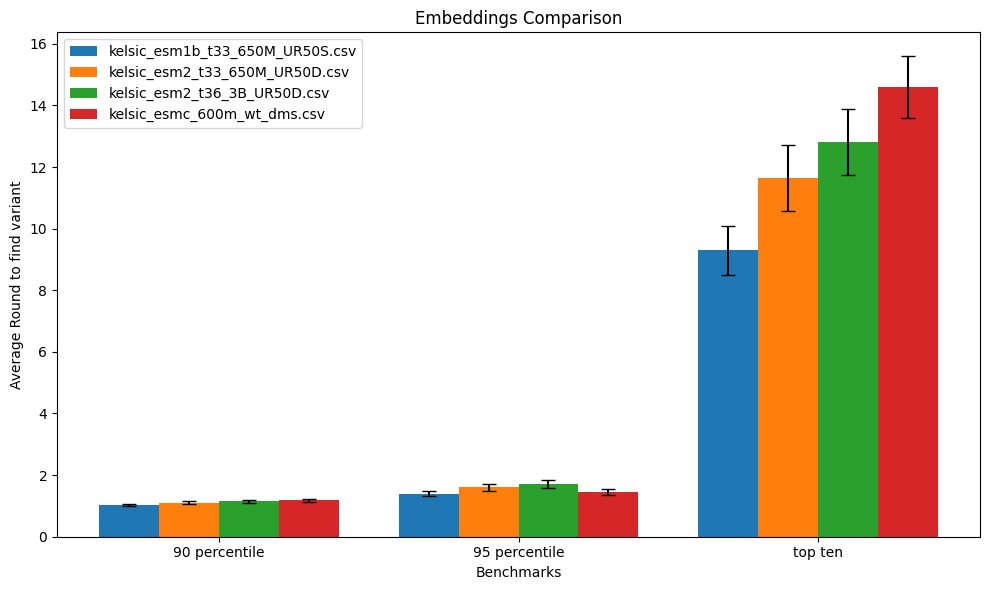

[WinError 183] Cannot create a file when that file already exists: '../EvolveTest\\kelsic'


In [3]:
from evolve.evolvetest import digivolve
from sklearn.ensemble import RandomForestRegressor
randomforest = RandomForestRegressor(
        n_estimators=100,
        criterion="friedman_mse",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        min_weight_fraction_leaf=0.0,
        max_features=1.0,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        bootstrap=True,
        oob_score=False,
        n_jobs=None,
        random_state=1,
        verbose=0,
        warm_start=False,
        ccp_alpha=0.0,
        max_samples=None,
    )

wt_aa_seq = 'MAKEDNIEMQGTVLETLPNTMFRVELENGHVVTAHISGKMRKNYIRILTGDKVTVELTPYDLSKGRIVFRSR'
dataset = 'kelsic'
exp_activity_file_path = r'..\EvolveTest\Kelsic_Data_foldy.xlsx'
embeddings_dir = '../EvolveTest'
embeddings_paths = [
    'kelsic_esm1b_t33_650M_UR50S.csv',
    'kelsic_esm2_t33_650M_UR50D.csv',
    'kelsic_esm2_t36_3B_UR50D.csv',
    'kelsic_esmc_600m_wt_dms.csv'
]
model_type = randomforest
rounds_evo = 100
num_var = 12


digivolve(wt_aa_seq,dataset,embeddings_dir, embeddings_paths,num_var,rounds_evo,model_type)


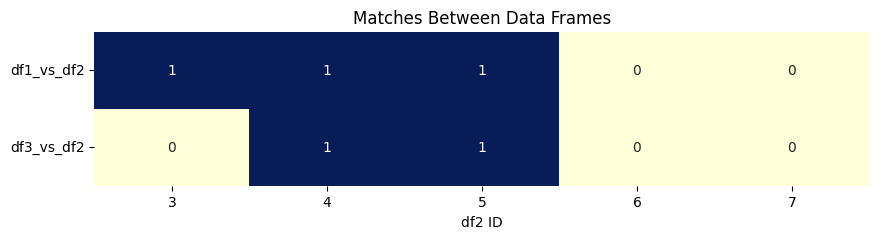

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data frames
data1 = {'id': [1, 2, 3, 4, 5], 'value': ['A', 'B', 'C', 'D', 'E']}
data2 = {'id': [3, 4, 5, 6, 7], 'value': ['C', 'D', 'E', 'F', 'G']}
data3 = {'id': [2, 4, 5, 8, 9], 'value': ['B', 'D', 'E', 'H', 'I']}

df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)
df3 = pd.DataFrame(data3)

# Find matches between df1 and df2
matches_df1_df2 = pd.merge(df1, df2, on='id', suffixes=('_df1', '_df2'))
match_vector_df1_df2 = pd.Series(0, index=df2['id'], dtype=int)
match_vector_df1_df2[matches_df1_df2['id']] = 1

# Find matches between df3 and df2
matches_df3_df2 = pd.merge(df3, df2, on='id', suffixes=('_df3', '_df2'))
match_vector_df3_df2 = pd.Series(0, index=df2['id'], dtype=int)
match_vector_df3_df2[matches_df3_df2['id']] = 1

# Combine match vectors into a DataFrame
match_matrix = pd.DataFrame({
    'df1_vs_df2': match_vector_df1_df2,
    'df3_vs_df2': match_vector_df3_df2
}).T

# Visualize with heatmap
plt.figure(figsize=(10, 2))
sns.heatmap(match_matrix, annot=True, cmap='YlGnBu', cbar=False, xticklabels=match_vector_df1_df2.index, yticklabels=match_matrix.index)
plt.title('Matches Between Data Frames')
plt.xlabel('df2 ID')
plt.yticks(rotation=0)  # Rotate y-axis labels for better readability
plt.show()

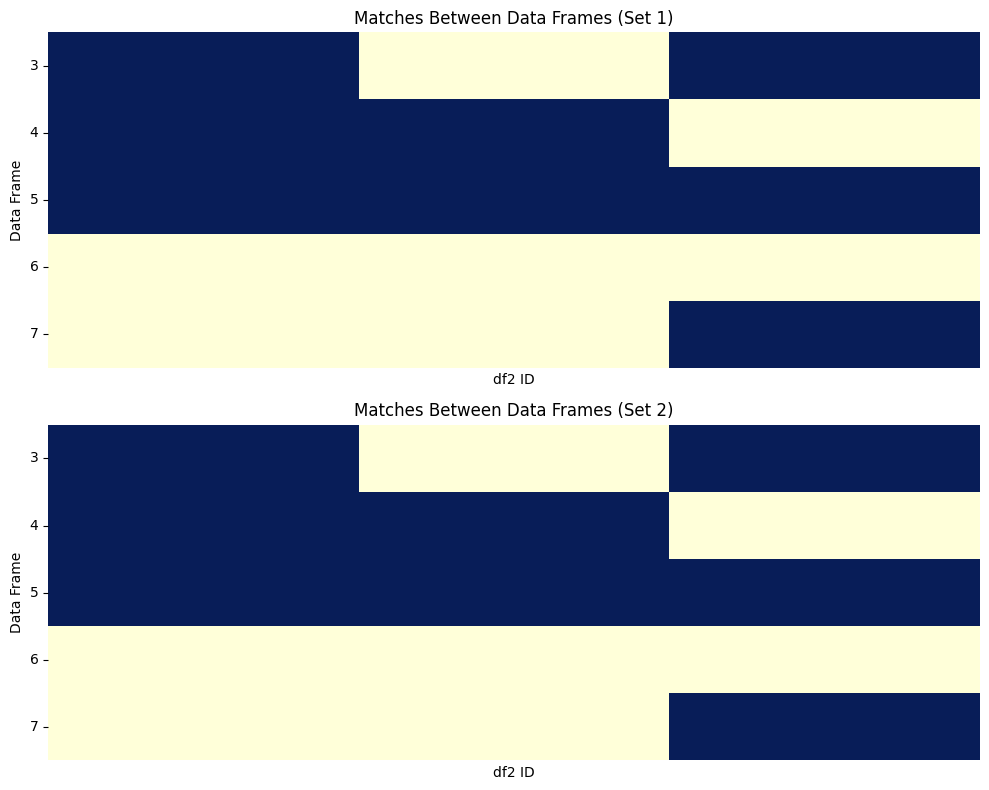

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data frames for the first set
data1_1 = {'id': [1, 2, 3, 4, 5], 'value': ['A', 'B', 'C', 'D', 'E']}
data2_1 = {'id': [3, 4, 5, 6, 7], 'value': ['C', 'D', 'E', 'F', 'G']}
data3_1 = {'id': [2, 4, 5, 8, 9], 'value': ['B', 'D', 'E', 'H', 'I']}
data4_1 = {'id': [1, 3, 5, 7, 9], 'value': ['A', 'C', 'E', 'G', 'I']}

df1_1 = pd.DataFrame(data1_1)
df2_1 = pd.DataFrame(data2_1)
df3_1 = pd.DataFrame(data3_1)
df4_1 = pd.DataFrame(data4_1)

# Sample data frames for the second set
data1_2 = {'id': [1, 2, 3, 4, 5], 'value': ['A', 'B', 'C', 'D', 'E']}
data2_2 = {'id': [3, 4, 5, 6, 7], 'value': ['C', 'D', 'E', 'F', 'G']}
data3_2 = {'id': [2, 4, 5, 8, 9], 'value': ['B', 'D', 'E', 'H', 'I']}
data4_2 = {'id': [1, 3, 5, 7, 9], 'value': ['A', 'C', 'E', 'G', 'I']}

df1_2 = pd.DataFrame(data1_2)
df2_2 = pd.DataFrame(data2_2)
df3_2 = pd.DataFrame(data3_2)
df4_2 = pd.DataFrame(data4_2)

# List of data frame sets
data_frame_sets = [
    {'df2': df2_1, 'data_frames': [df1_1, df3_1, df4_1], 'data_frame_names': ['df1', 'df3', 'df4']},
    {'df2': df2_2, 'data_frames': [df1_2, df3_2, df4_2], 'data_frame_names': ['df1', 'df3', 'df4']}
]

# Number of sets
num_sets = len(data_frame_sets)

# Create subplots
fig, axes = plt.subplots(nrows=num_sets, ncols=1, figsize=(10, 4 * num_sets))

# Iterate over each set of data frames
for i, data_set in enumerate(data_frame_sets):
    df2 = data_set['df2']
    data_frames = data_set['data_frames']
    data_frame_names = data_set['data_frame_names']
    
    # Initialize an empty dictionary to store match vectors
    match_vectors = {}
    
    # Iterate over the list of data frames
    for df, name in zip(data_frames, data_frame_names):
        # Find matches between the current data frame and df2
        matches = pd.merge(df, df2, on='id', suffixes=(f'_{name}', '_df2'))
        match_vector = pd.Series(0, index=df2['id'], dtype=int)
        match_vector[matches['id']] = 1
        match_vectors[name] = match_vector
    
    # Combine match vectors into a DataFrame
    match_matrix = pd.DataFrame(match_vectors)
    
    # Plot heatmap in the current subplot
    sns.heatmap(match_matrix, annot=False, cmap='YlGnBu', cbar=False, xticklabels=False, yticklabels=match_matrix.index, ax=axes[i])
    axes[i].set_title(f'Matches Between Data Frames (Set {i+1})')
    axes[i].set_xlabel('df2 ID')
    axes[i].set_ylabel('Data Frame')
    axes[i].tick_params(axis='y', rotation=0)  # Rotate y-axis labels for better readability

# Adjust layout
plt.tight_layout()
plt.show()

,id,value
0,1,A
1,2,B
2,3,C
3,4,D
4,5,E


,id,value
0,3,C
1,4,D
2,5,E
3,6,F
4,7,G


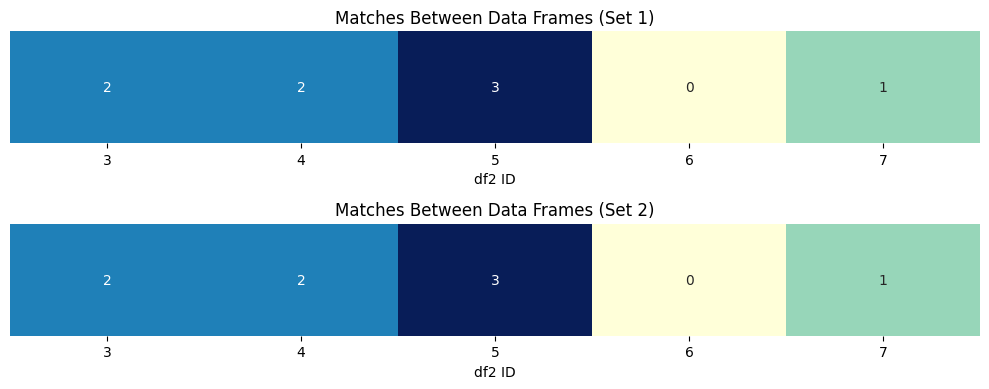

In [203]:
# Sample data frames for the first set
data1_1 = {'id': [1, 2, 3, 4, 5], 'value': ['A', 'B', 'C', 'D', 'E']}
data2_1 = {'id': [3, 4, 5, 6, 7], 'value': ['C', 'D', 'E', 'F', 'G']}
data3_1 = {'id': [2, 4, 5, 8, 9], 'value': ['B', 'D', 'E', 'H', 'I']}
data4_1 = {'id': [1, 3, 5, 7, 9], 'value': ['A', 'C', 'E', 'G', 'I']}

df1_1 = pd.DataFrame(data1_1)
display(df1_1)
df2_1 = pd.DataFrame(data2_1)
display(df2_1)
df3_1 = pd.DataFrame(data3_1)
df4_1 = pd.DataFrame(data4_1)

# Sample data frames for the second set
data1_2 = {'id': [1, 2, 3, 4, 5], 'value': ['A', 'B', 'C', 'D', 'E']}
data2_2 = {'id': [3, 4, 5, 6, 7], 'value': ['C', 'D', 'E', 'F', 'G']}
data3_2 = {'id': [2, 4, 5, 8, 9], 'value': ['B', 'D', 'E', 'H', 'I']}
data4_2 = {'id': [1, 3, 5, 7, 9], 'value': ['A', 'C', 'E', 'G', 'I']}

df1_2 = pd.DataFrame(data1_2)
df2_2 = pd.DataFrame(data2_2)
df3_2 = pd.DataFrame(data3_2)
df4_2 = pd.DataFrame(data4_2)

# List of data frame sets
data_frame_sets = [
    {'df2': df2_1, 'data_frames': [df1_1, df3_1, df4_1], 'data_frame_names': ['df1', 'df3', 'df4']},
    {'df2': df2_2, 'data_frames': [df1_2, df3_2, df4_2], 'data_frame_names': ['df1', 'df3', 'df4']}
]

# Number of sets
num_sets = len(data_frame_sets)

# Create subplots
fig, axes = plt.subplots(nrows=num_sets, ncols=1, figsize=(10, 2 * num_sets))

# Iterate over each set of data frames
for i, data_set in enumerate(data_frame_sets):
    df2 = data_set['df2']
    data_frames = data_set['data_frames']
    
    # Initialize a match vector with zeros
    match_vector = pd.Series(0, index=df2['id'], dtype=int)
    
    # Iterate over the list of data frames and count matches
    for df in data_frames:
        matches = pd.merge(df, df2, on='id', suffixes=('_df', '_df2'))
        match_vector[matches['id']] += 1
    
    # Reshape to a single row DataFrame
    match_matrix = match_vector.to_frame().T
    
    # Plot heatmap in the current subplot
    sns.heatmap(match_matrix, annot=True, cmap='YlGnBu', cbar=False, xticklabels=match_vector.index, yticklabels=False, ax=axes[i])
    axes[i].set_title(f'Matches Between Data Frames (Set {i+1})')
    axes[i].set_xlabel('df2 ID')
    axes[i].set_yticks([])  # Remove y-axis ticks

# Adjust layout
plt.tight_layout()
plt.show()